In [1]:

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn for preprocessing, modeling, and evaluation
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Optional: Ignore warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:

# Load the two datasets
try:
    df1 = pd.read_csv('bt_dataset_t3.csv')
    df2 = pd.read_csv('Brain Tumor.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError:
    print("Dataset files not found. Please check the file paths.")
    # Create dummy dataframes to allow the rest of the script to run for demonstration
    df1 = pd.DataFrame(columns=['Image', 'Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity', 'Correlation', 'Coarseness', 'PSNR', 'SSIM', 'MSE', 'DC', 'Target'])
    df2 = pd.DataFrame(columns=['Image', 'Class', 'Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity', 'Correlation'])


# Standardize column names before merging
df1 = df1.rename(columns={'Target': 'Class'})

# Concatenate the two dataframes
df = pd.concat([df1, df2], ignore_index=True)

# Set 'Image' as the index for easier data handling
df.set_index('Image', inplace=True)

print("Dataframes combined. Shape of the new dataframe:", df.shape)
df.info()

Datasets loaded successfully.
Dataframes combined. Shape of the new dataframe: (5406, 18)
<class 'pandas.core.frame.DataFrame'>
Index: 5406 entries, Image1 to Image3762
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mean                5406 non-null   float64
 1   Variance            5406 non-null   float64
 2   Standard Deviation  5406 non-null   float64
 3   Entropy             5406 non-null   float64
 4   Skewness            5037 non-null   float64
 5   Kurtosis            5037 non-null   float64
 6   Contrast            5406 non-null   float64
 7   Energy              5406 non-null   float64
 8   ASM                 5406 non-null   float64
 9   Homogeneity         5406 non-null   float64
 10  Dissimilarity       5406 non-null   float64
 11  Correlation         5406 non-null   float64
 12  Coarseness          5406 non-null   float64
 13  PSNR                1644 non-null   float64
 14  SSIM     

In [3]:

# --- 3.1: Handle Infinite Values ---
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Infinite values replaced with NaN.")

# --- 3.2: Drop Columns with High Percentage of Missing Data ---
# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().sum() / len(df) * 100
cols_to_drop_missing = missing_percentage[missing_percentage > 70].index
df.drop(columns=cols_to_drop_missing, inplace=True)
print(f"\nDropped columns with >70% missing values: {list(cols_to_drop_missing)}")

# --- 3.3: Drop Constant and Redundant Features ---
# Drop 'Coarseness' due to zero variance
df.drop(columns=['Coarseness'], inplace=True, errors='ignore') # errors='ignore' in case it's already dropped
print("Dropped 'Coarseness' column (zero variance).")

# Drop redundant, perfectly correlated features
df.drop(columns=['Standard Deviation', 'ASM'], inplace=True)
print("Dropped redundant columns: 'Standard Deviation' and 'ASM'.")

# --- 3.4: Impute Remaining Missing Values using SimpleImputer ---
# Identify columns that still have missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()
if cols_with_missing:
    imputer = SimpleImputer(strategy='median')
    # Fit and transform the data
    df[cols_with_missing] = imputer.fit_transform(df[cols_with_missing])
    print(f"\nImputed remaining missing values in: {cols_with_missing} using median strategy.")
else:
    print("\nNo remaining missing values to impute.")

# --- 3.5: Final Check for Missing Values ---
print("\nMissing values after all cleaning steps:")
print(df.isnull().sum().sum()) # Should be 0

print("\nCleaned DataFrame Head:")
print(df.head())

Infinite values replaced with NaN.

Dropped columns with >70% missing values: ['PSNR', 'SSIM', 'DC']
Dropped 'Coarseness' column (zero variance).
Dropped redundant columns: 'Standard Deviation' and 'ASM'.

Imputed remaining missing values in: ['Skewness', 'Kurtosis', 'MSE'] using median strategy.

Missing values after all cleaning steps:
0

Cleaned DataFrame Head:
             Mean     Variance   Entropy  Skewness   Kurtosis    Contrast  \
Image                                                                       
Image1  23.448517  2538.985627  0.651174  1.984202   5.421042  181.467713   
Image2   4.398331   834.853030  0.953532  6.495203  43.349355   76.745886   
Image3   3.244263   642.059166  0.966065  7.772860  61.756034   81.752406   
Image4   8.511353  1126.214187  0.868765  3.763142  15.107579  362.291213   
Image5  21.000793  2235.316978  0.684724  1.936029   4.722343  312.439226   

          Energy  Homogeneity  Dissimilarity  Correlation       MSE  Class  
Image           

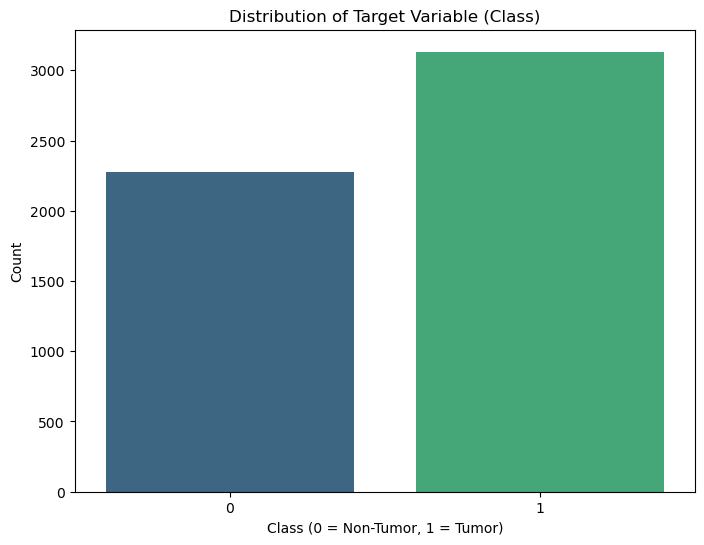

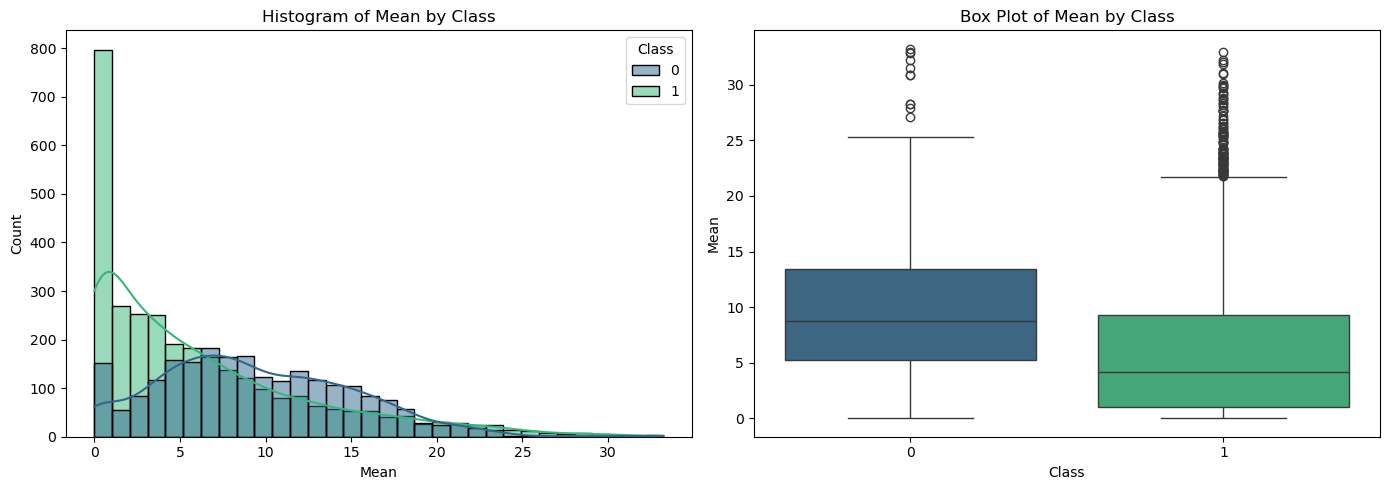

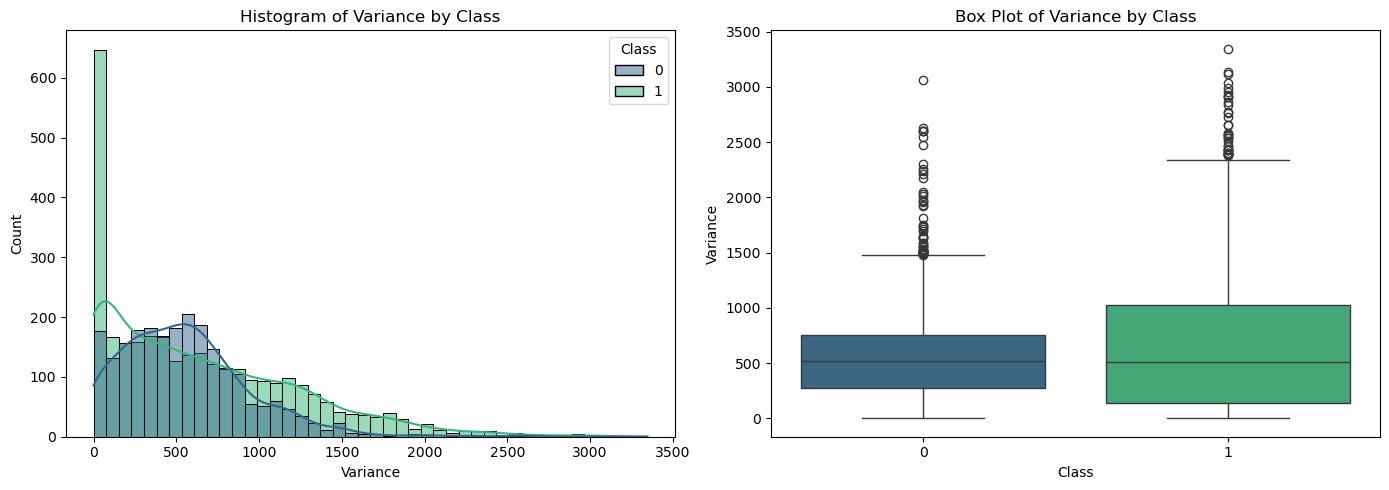

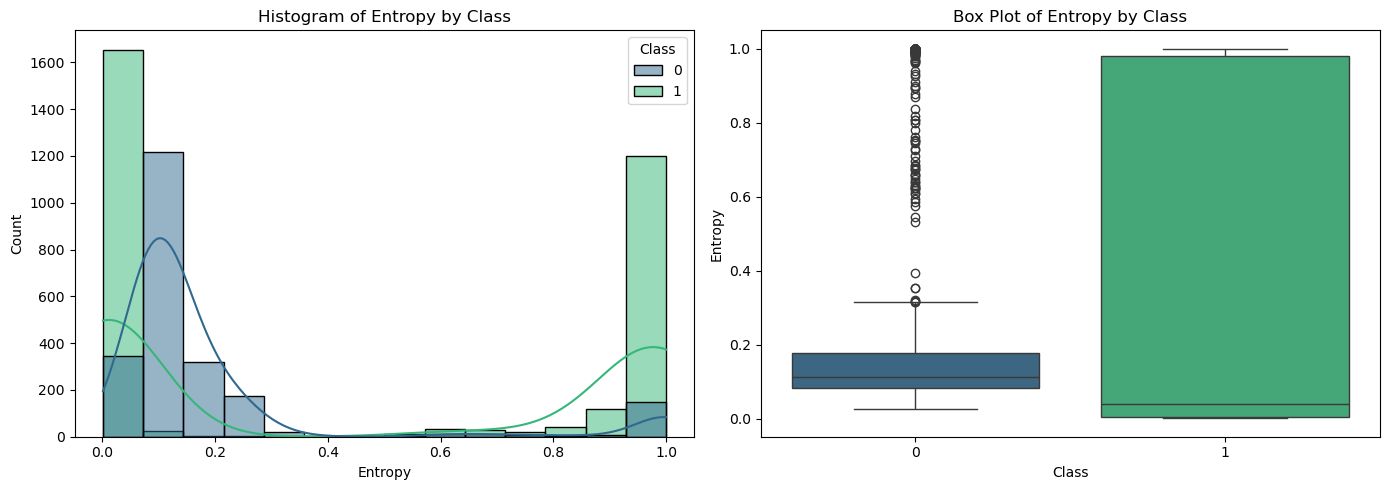

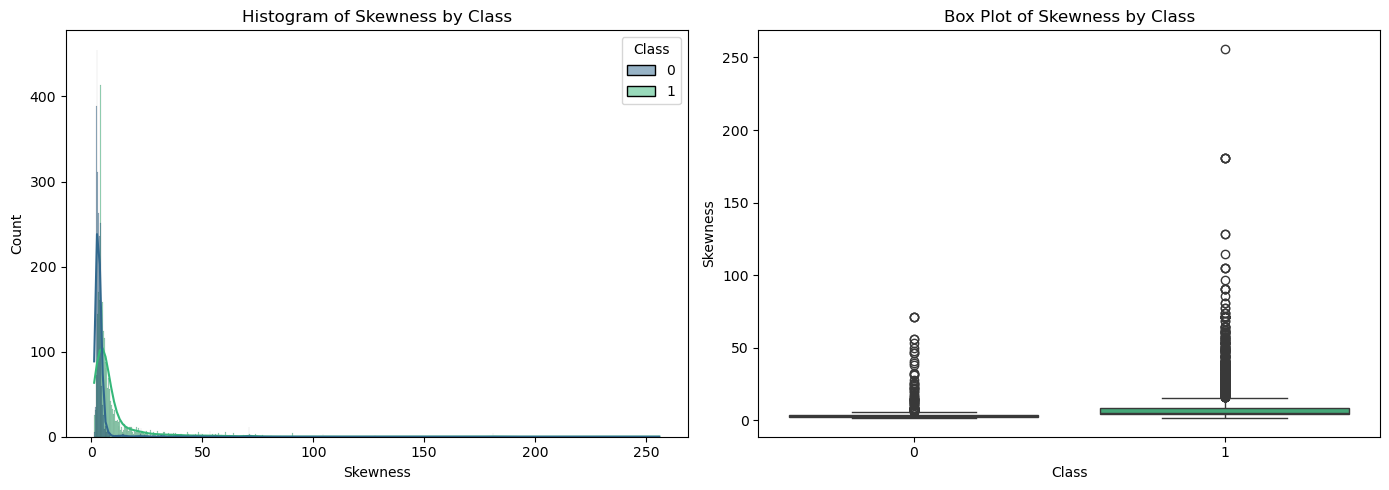

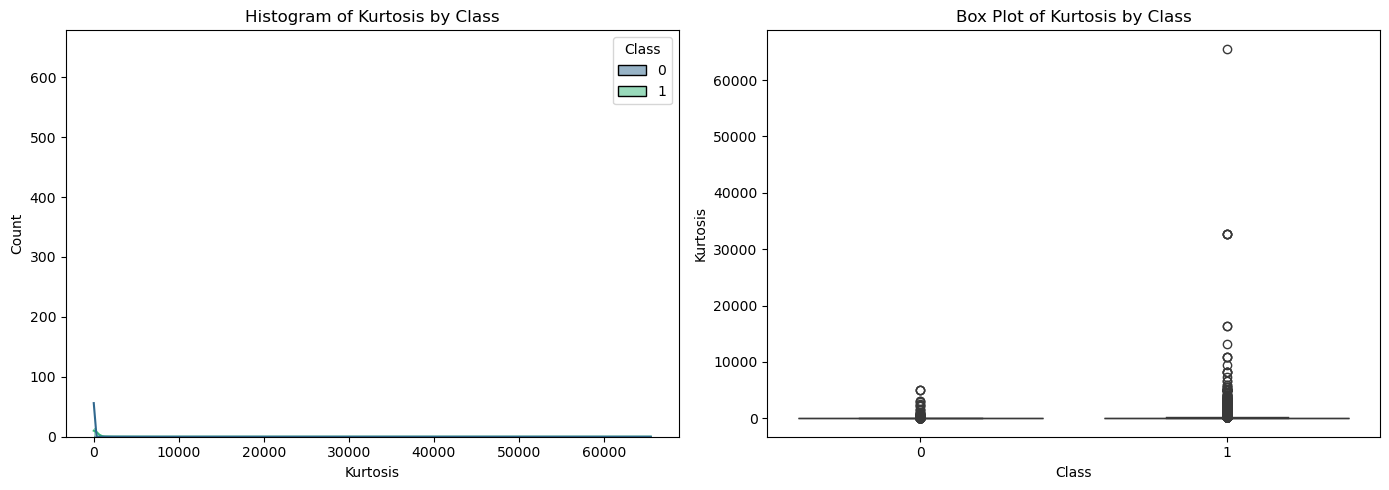

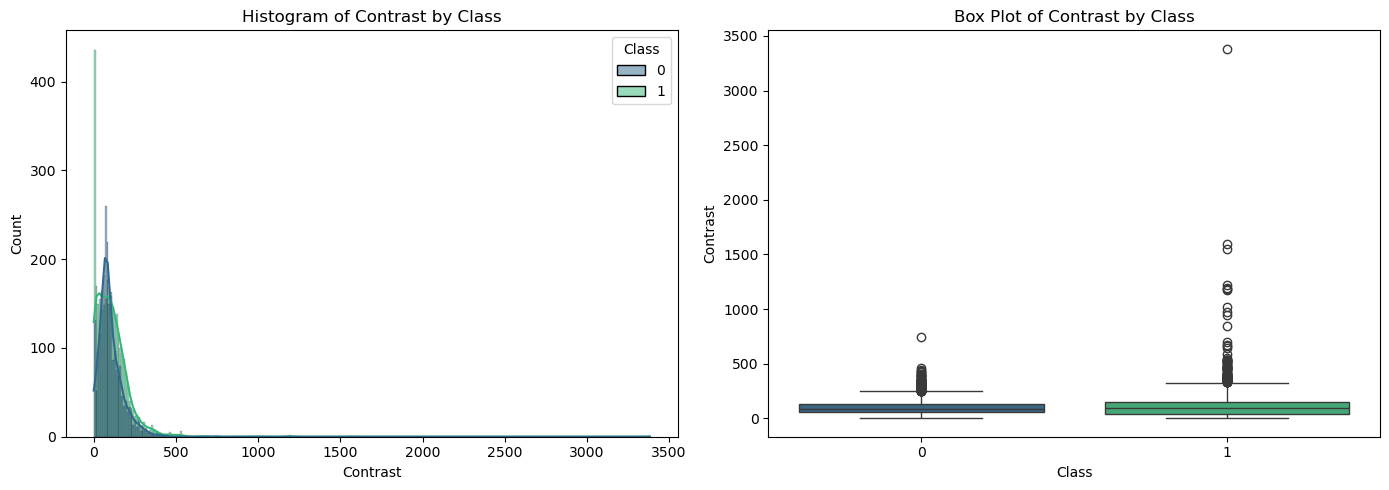

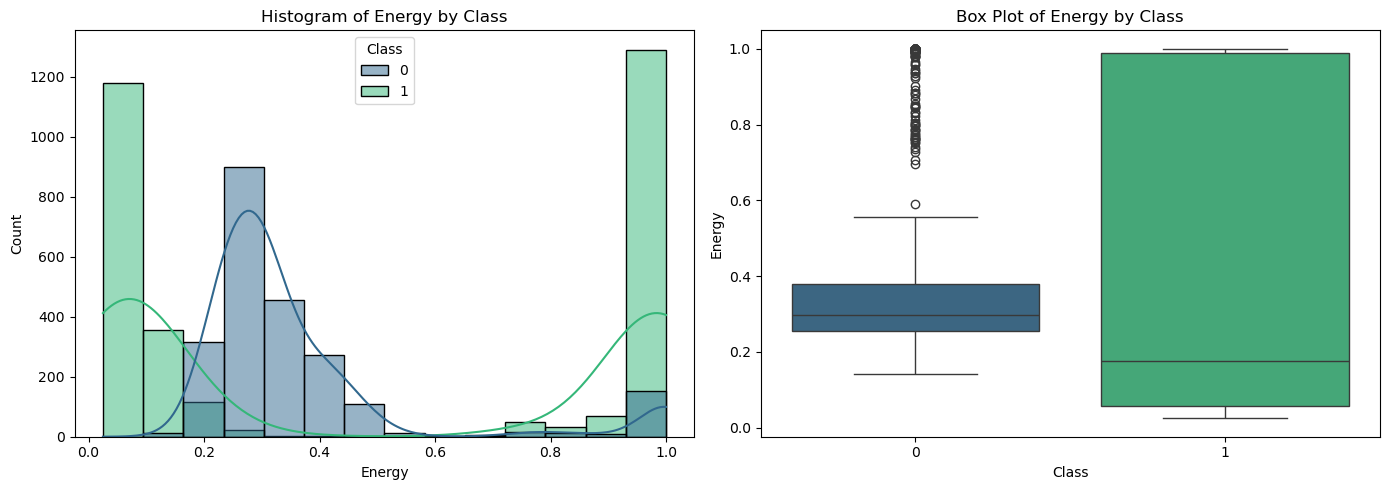

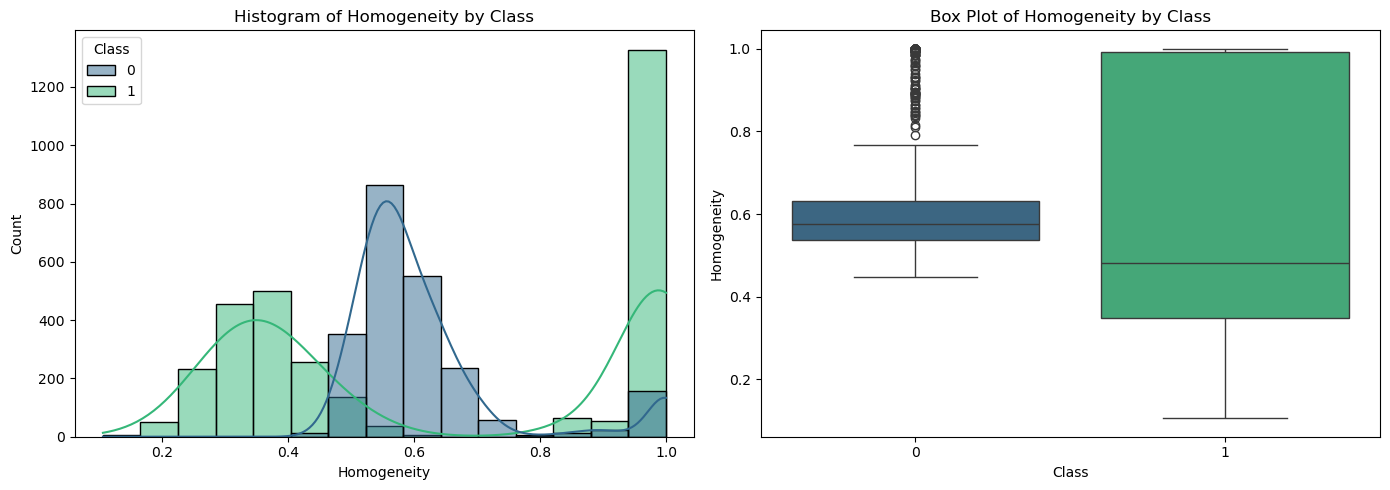

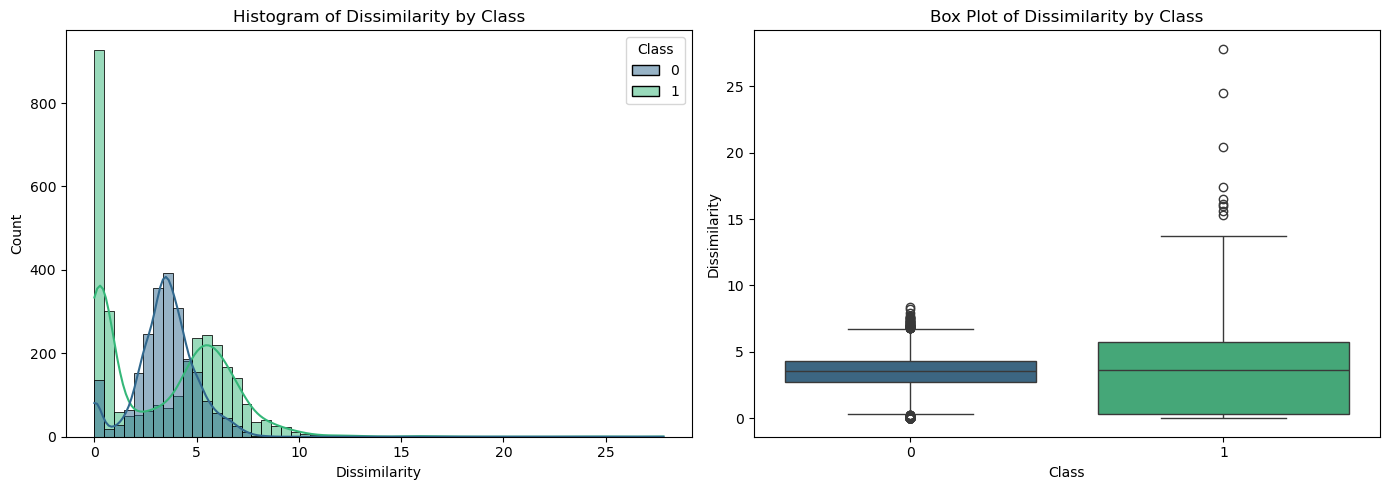

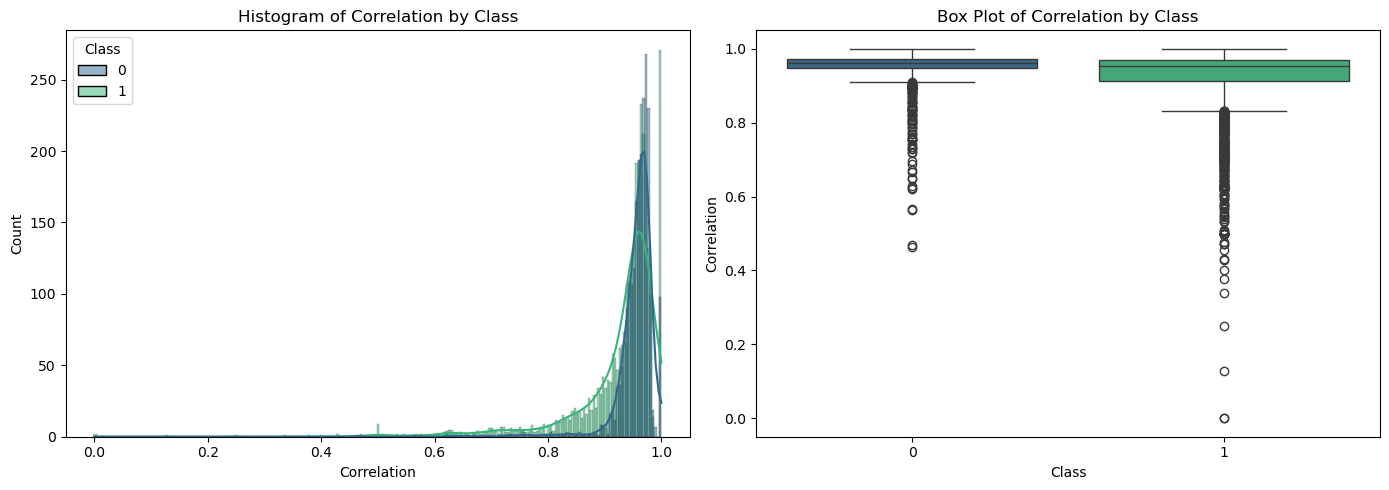

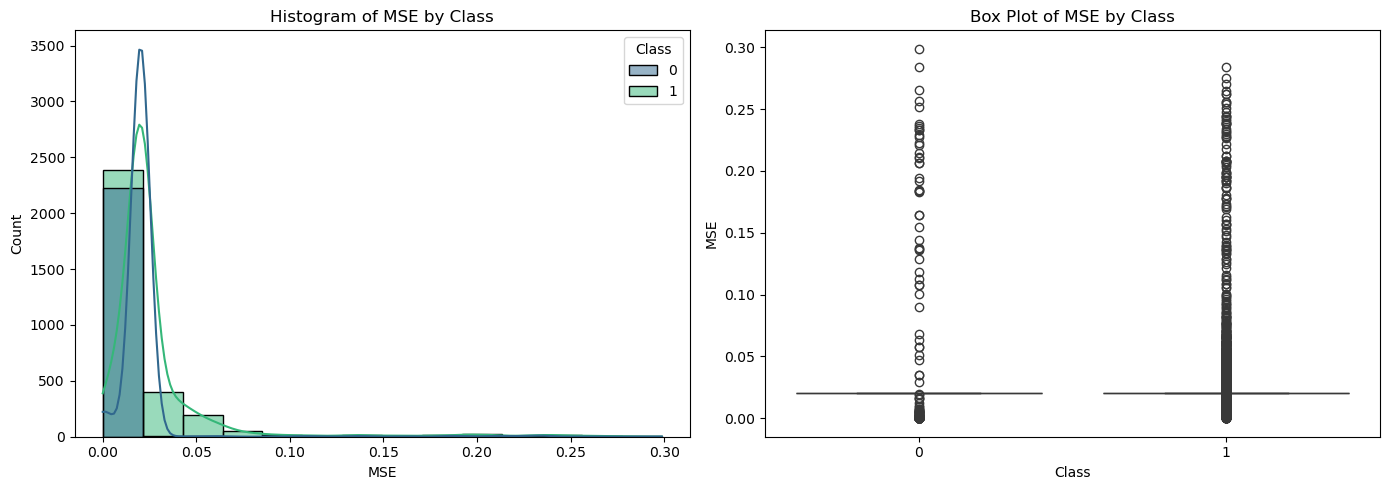

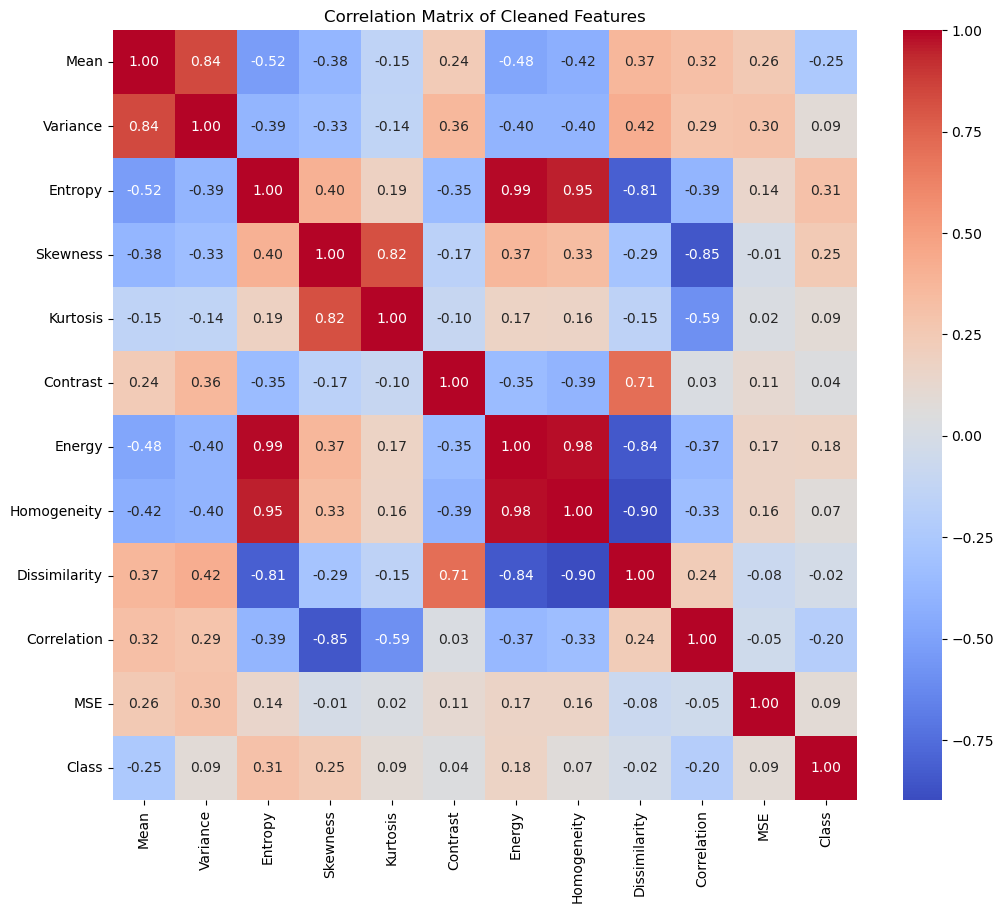

In [4]:

# --- 4.1: Target Variable Analysis ---
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribution of Target Variable (Class)')
plt.xlabel('Class (0 = Non-Tumor, 1 = Tumor)')
plt.ylabel('Count')
plt.show()

# --- 4.2: Comprehensive Univariate Analysis (Histograms and Box Plots) ---
features = df.drop('Class', axis=1).columns
for feature in features:
    plt.figure(figsize=(14, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=feature, hue='Class', kde=True, palette='viridis')
    plt.title(f'Histogram of {feature} by Class')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='Class', y=feature, palette='viridis')
    plt.title(f'Box Plot of {feature} by Class')

    plt.tight_layout()
    plt.show()

# --- 4.3: Bivariate Analysis (Correlation Matrix) ---
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Cleaned Features')
plt.show()

In [6]:
# --- 5.1: Separate Features (X) and Target (y) ---
X = df.drop('Class', axis=1)
y = df['Class']
print("Features (X) and target (y) have been separated.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


# --- 5.2: Feature Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert back to a DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("\nFeatures have been scaled using StandardScaler.")
print("Scaled Features Head:")
print(X_scaled.head())

# --- 5.3: Train-Test Split ---
# Stratify=y ensures that the class distribution is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("\nData has been split into training and testing sets.")
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Features (X) and target (y) have been separated.
Shape of X: (5406, 11)
Shape of y: (5406,)

Features have been scaled using StandardScaler.
Scaled Features Head:
       Mean  Variance   Entropy  Skewness  Kurtosis  Contrast    Energy  \
0  2.509283  3.734334  0.758726 -0.433291 -0.128756  0.707803  0.932887   
1 -0.498122  0.436040  1.495622 -0.053399 -0.102737 -0.284208  1.450784   
2 -0.680312  0.062894  1.526167  0.054198 -0.090109 -0.236782  1.470804   
3  0.151190  0.999960  1.289032 -0.283478 -0.122111  2.420713  1.312696   
4  2.122867  3.146593  0.840494 -0.437347 -0.129235  1.948474  0.994171   

   Homogeneity  Dissimilarity  Correlation       MSE  
0     0.846855      -0.268872     0.427902  5.002000  
1     1.372167      -1.158066     0.306780 -0.522324  
2     1.389075      -1.161353     0.094170 -0.643659  
3     1.248561      -0.268746    -1.075544  1.482682  
4     0.977537      -0.172104     0.016125  5.471877  

Data has been split into training and testing sets.
Tra

In [7]:

# --- 6.1: Logistic Regression ---
print("--- Logistic Regression Model ---")
# Initialize and train the model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))


# --- 6.2: Random Forest Classifier ---
print("\n\n--- Random Forest Classifier Model ---")
# Initialize and train the model
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Model ---
Accuracy: 0.9371534195933456

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       455
           1       0.95      0.95      0.95       627

    accuracy                           0.94      1082
   macro avg       0.94      0.94      0.94      1082
weighted avg       0.94      0.94      0.94      1082



--- Random Forest Classifier Model ---
Accuracy: 0.9704251386321626

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       455
           1       0.97      0.98      0.97       627

    accuracy                           0.97      1082
   macro avg       0.97      0.97      0.97      1082
weighted avg       0.97      0.97      0.97      1082




### **Conclusion and Next Steps**

This notebook presented an end-to-end workflow for the initial analysis of a brain tumor dataset. The primary goal was to clean the data, explore its characteristics, and establish a baseline performance for predicting the presence of a brain tumor using classical machine learning models.

#### **Summary of a nalysis**

1.  **Data Preparation and Cleaning:** We began by merging two separate datasets. A crucial part of this process was a robust cleaning strategy, where we:
    *   Dropped columns with over 70% missing values (`PSNR`, `SSIM`, `DC`), as imputing them would introduce significant bias.
    *   Removed uninformative features with zero variance (`Coarseness`).
    *   Reduced multicollinearity by dropping perfectly correlated, redundant features (`Standard Deviation`, `ASM`).
    *   Imputed the few remaining missing values using a robust median strategy.

2.  **Exploratory Data Analysis (EDA):** Through visualizations, we gained key insights into the data:
    *   **Feature Correlation:** The correlation matrix revealed strong relationships between features. Notably, `Energy` and `Homogeneity` are highly correlated with each other and show strong negative correlations with `Contrast` and `Dissimilarity`. This confirms that reducing multicollinearity was a necessary step.
    *   **Feature Distributions:** The histograms and box plots showed that several features exhibit different distributions for tumor (Class 1) and non-tumor (Class 0) cases. For example, **Dissimilarity** is visibly higher on average for tumorous images, suggesting it is a strong predictive feature.

3.  **Baseline Modeling:** After scaling the features, we trained two baseline models:
    *   **Logistic Regression:** Achieved a strong accuracy of **93.7%**, demonstrating that even a simple linear model can effectively separate the classes.
    *   **Random Forest Classifier:** Performed exceptionally well, achieving an impressive accuracy of **97.0%**. The high precision (97%) and recall (98% for the tumor class) indicate that this model is both reliable and robust, making very few errors in identifying actual tumors.

#### **Final Thoughts**

The results are very promising. The high accuracy of the baseline models, especially the Random Forest, suggests that the textural and statistical features extracted from the images are highly effective for this classification task.

The thorough data cleaning and preprocessing were essential for achieving these strong results. By removing uninformative and redundant features, we created a cleaner, more efficient dataset that allowed the models to learn meaningful patterns.

#### **Next Steps and Future Work**

This notebook serves as a foundational analysis. For the next version, I plan to build upon these results by exploring more advanced techniques:

*   **Hyperparameter Tuning:** Fine-tune the Random Forest model using methods like GridSearchCV or RandomizedSearchCV to see if we can further improve its performance.
*   **Explore Modern ML Models:** Implement and evaluate more powerful, state-of-the-art gradient boosting models like **XGBoost**, **LightGBM**, and **CatBoost**, which often provide a performance lift in classification tasks.
*   **Feature Importance Analysis:** Investigate the feature importances from the tree-based models (like Random Forest and XGBoost) to identify the most influential features in predicting brain tumors.
*   **Robust Evaluation:** Re-evaluate the top models using k-fold cross-validation to ensure that their performance is stable and not just the result of a single favorable train-test split.

Thank you for following along with this initial analysis. Stay tuned for the next version where we will dive deeper into advanced modeling